# Train logistic regression model (t+1 target)
Train a logistic regression classifier on `data/processed/log_reg_t1`, using `target_t+1` as the label and all columns except the target, `client_nr`, and `yearmonth` as features.

Raw-magnitude features are standardized inside the pipeline (already-scaled z-scores/slopes and one-hot dummies are passed through), and `class_weight="balanced"` handles the rare positive class. Hyperparameters (`C`, `penalty`) are tuned with **Optuna**, maximizing PR-AUC on the validation split. The classification threshold is **not** tuned automatically: it is chosen manually below by inspecting the validation precision-recall curve.

In [1]:
import sys
from pathlib import Path

import pandas as pd

# walk up to the project root so this notebook works from its subfolder
PROJECT_ROOT = Path.cwd()
while not (PROJECT_ROOT / "models").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.append(str(PROJECT_ROOT / "models"))

import train_logistic_regression
from train_logistic_regression import (
    evaluate_all_splits,
    load_split,
    plot_precision_recall_curve,
    save_model,
    train_model,
)

HORIZON = "t1"
train_logistic_regression.set_horizon(HORIZON)
TARGET_COLUMN = train_logistic_regression.TARGET_COLUMN

c:\Users\SVisbee\Repos\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using dataset log_reg_t1 with target 'target_t+1'


## Tune hyperparameters and train

In [2]:
model, feature_columns, trials_df = train_model(n_trials=50)

Train observations: 18,707
Validation observations: 3,753
Number of features: 48

Class distribution in training data:
  Negative: 17,379
  Positive: 1,328


Best trial: 2. Best value: 0.157505: 100%|██████████| 50/50 [00:33<00:00,  1.49it/s]



Best validation PR-AUC: 0.1575
Best hyperparameters:
  C: 0.1
  penalty: l1


In [3]:
trials_df.sort_values("value", ascending=False).head(10)

,number,value,datetime_start,datetime_complete,duration,params_C,params_penalty,state
25,25,0.157505,2026-08-31 17:01:36.488023,2026-08-31 17:01:36.958319,0 days 00:00:00.470296,0.1,l1,COMPLETE
15,15,0.157505,2026-08-31 17:01:30.552866,2026-08-31 17:01:31.143320,0 days 00:00:00.590454,0.1,l1,COMPLETE
40,40,0.157505,2026-08-31 17:01:47.038273,2026-08-31 17:01:47.579060,0 days 00:00:00.540787,0.1,l1,COMPLETE
34,34,0.157505,2026-08-31 17:01:41.423633,2026-08-31 17:01:41.908093,0 days 00:00:00.484460,0.1,l1,COMPLETE
33,33,0.157505,2026-08-31 17:01:40.911284,2026-08-31 17:01:41.418636,0 days 00:00:00.507352,0.1,l1,COMPLETE
32,32,0.157505,2026-08-31 17:01:40.293901,2026-08-31 17:01:40.909292,0 days 00:00:00.615391,0.1,l1,COMPLETE
31,31,0.157505,2026-08-31 17:01:39.770956,2026-08-31 17:01:40.293901,0 days 00:00:00.522945,0.1,l1,COMPLETE
41,41,0.157505,2026-08-31 17:01:47.579060,2026-08-31 17:01:48.078707,0 days 00:00:00.499647,0.1,l1,COMPLETE
43,43,0.157505,2026-08-31 17:01:48.284742,2026-08-31 17:01:48.758232,0 days 00:00:00.473490,0.1,l1,COMPLETE
24,24,0.157505,2026-08-31 17:01:35.989563,2026-08-31 17:01:36.486515,0 days 00:00:00.496952,0.1,l1,COMPLETE


## Select the classification threshold
Inspect the precision-recall curve on the **validation** split (train would be optimistic, test must stay untouched) and pick the threshold matching the business objective.

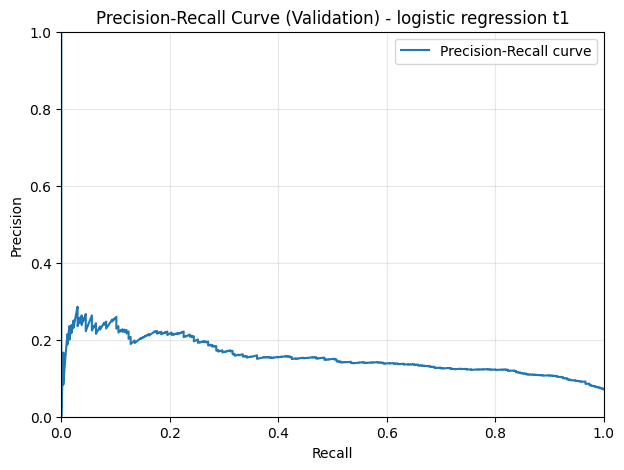

In [4]:
val_df = load_split("val")

threshold_table = plot_precision_recall_curve(
    model,
    val_df,
    feature_columns,
    title=f"Precision-Recall Curve (Validation) - logistic regression {HORIZON}",
)

In [5]:
# inspect candidate operating points to pick a threshold
threshold_table = threshold_table.sort_values(by="recall", ascending=False)
threshold_table[threshold_table["precision"] >= 0.25].head(20)

,threshold,precision,recall
3649,0.830935,0.259615,0.101504
3648,0.829747,0.257143,0.101504
3646,0.828358,0.252336,0.101504
3647,0.828675,0.254717,0.101504
3645,0.827039,0.250000,0.101504
3650,0.831057,0.252427,0.097744
3651,0.832861,0.254902,0.097744
3653,0.834223,0.250000,0.093985
3654,0.834422,0.252525,0.093985
3696,0.862168,0.263158,0.056391


### Chosen threshold
Set `SELECTED_THRESHOLD` below based on the curve and table above.

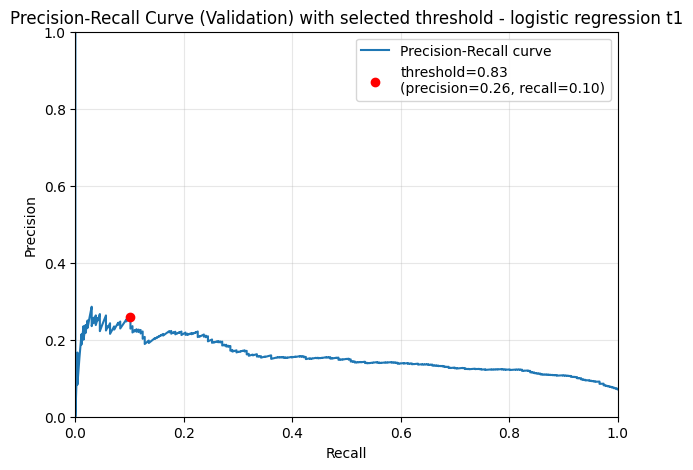

In [9]:
SELECTED_THRESHOLD = 0.830935

plot_precision_recall_curve(
    model,
    val_df,
    feature_columns,
    threshold=SELECTED_THRESHOLD,
    title=f"Precision-Recall Curve (Validation) with selected threshold - logistic regression {HORIZON}",
);

## Final evaluation

In [10]:
evaluate_all_splits(model, feature_columns, threshold=SELECTED_THRESHOLD)

,pr_auc,precision,recall,f1,precision_at_k (k=90),recall_at_k (k=90)
train,0.129620,0.141667,0.025602,0.043367,0.144444,0.009789
val,0.157505,0.259615,0.101504,0.145946,0.244444,0.082707
test,0.134051,0.196891,0.102151,0.134513,0.188889,0.045699


## Save the model
Persist the fitted model together with its feature list and chosen threshold, so it can be reloaded for comparison and inference.

In [11]:
save_model(model, feature_columns, threshold=SELECTED_THRESHOLD)

Saved model to C:\Users\SVisbee\Repos\Credit_prediction_case\models\artifacts\log_reg_t1.joblib


WindowsPath('C:/Users/SVisbee/Repos/Credit_prediction_case/models/artifacts/log_reg_t1.joblib')